# Phase 7 — Full Model Comparison, Statistical Testing & Error Analysis

**Project:** Drug–Drug Interaction Detection using NLP  
**Author:** Carina Vima de Souza

---

## Overview

This is the **central evaluation notebook** of the project. It loads predictions from every model trained across Phases 5 and 6 and produces the definitive academic comparison.

### Models compared

| # | Phase | Model | Type |
|---|---|---|---|
| 1 | 5 | Rule-based Baseline | Pattern matching — no ML |
| 2 | 5 | Naive Bayes | Probabilistic classifier |
| 3 | 5 | Logistic Regression | Linear classifier |
| 4 | 5 | Random Forest | Ensemble (trees) |
| 5 | 5 | Linear SVM | Best classical ML |
| 6 | 6a | BioBERT | Transformer — PubMed + PMC |
| 7 | 6b | PubMedBERT | Transformer — PubMed only (from scratch) |
| 8 | 6c | SciBERT | Transformer — broad scientific domain |

### Research questions answered here

| RQ | Question |
|---|---|
| RQ1 | Does classical ML beat keyword matching? |
| RQ2 | Do transformers beat classical ML — and by how much? |
| RQ3 | Which transformer performs best, and why? |
| RQ4 | Are the improvements statistically significant? |
| RQ5 | Where do models still fail — what are the failure modes? |

**Input:** Saved `.pkl` models (Phase 5), `.npy` prediction files (Phase 6a/6b/6c), `*_results.csv` files  
**Output:** `full_comparison.csv`, `statistical_tests.csv`, five comparison visualisations, error analysis report

## 1. Configuration

In [1]:
import os, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import sparse
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────
FEATURES_DIR    = '../../data/features/'
MODELS_DIR      = '../../data/models/'
TRANSFORMER_DIR = '../../data/models/transformers/'
TEST_CSV        = '../../data/processed/test_processed.csv'

# Output Directories
FIG_DIR = Path('outputs/figures')
DAT_DIR = Path('outputs/data')

FIG_DIR.mkdir(parents=True, exist_ok=True)
DAT_DIR.mkdir(parents=True, exist_ok=True)

# ── Label definitions ─────────────────────────────────────────────
LABEL_ORDER = ['false', 'effect', 'mechanism', 'advise', 'int']
LABEL2ID    = {'advise': 0, 'effect': 1, 'false': 2, 'int': 3, 'mechanism': 4}
ID2LABEL    = {v: k for k, v in LABEL2ID.items()}
CLASS_NAMES = [ID2LABEL[i] for i in sorted(ID2LABEL)]  # alphabetical
NUM_LABELS  = 5

# Display order (pipeline order, not alphabetical)
MODEL_ORDER = [
    'Rule-based', 'Naive Bayes', 'Logistic Regression',
    'Random Forest', 'Linear SVM',
    'BioBERT', 'PubMedBERT', 'SciBERT',
]

# ── Colours (consistent with Phase 5 & 6 notebooks) ───────────────
LABEL_COLOURS = {
    'false': '#888780', 'effect': '#378ADD',
    'mechanism': '#7F77DD', 'advise': '#EF9F27', 'int': '#D85A30',
}
MODEL_COLOURS = {
    'Rule-based':          '#B4B2A9',
    'Naive Bayes':         '#9FE1CB',
    'Logistic Regression': '#FAC775',
    'Random Forest':       '#7F77DD',
    'Linear SVM':          '#378ADD',
    'BioBERT':             '#1D9E75',
    'PubMedBERT':          '#EF9F27',
    'SciBERT':             '#D85A30',
}
TYPE_COLOURS = {
    'Rule-based':    '#E0DFDB',
    'Classical ML':  '#C8E6F7',
    'Transformer':   '#C8F0E4',
}

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})

print('Configuration loaded.')
for path in [FEATURES_DIR, MODELS_DIR, TRANSFORMER_DIR, TEST_CSV]:
    status = 'FOUND ✓' if os.path.exists(path) else 'NOT FOUND ✗'
    print(f'  {path}  =>  {status}')

Configuration loaded.
  ../../data/features/  =>  FOUND ✓
  ../../data/models/  =>  FOUND ✓
  ../../data/models/transformers/  =>  FOUND ✓
  ../../data/processed/test_processed.csv  =>  FOUND ✓


## 2. Load All Predictions

This cell loads predictions from every model. Each source is independent:
- **Classical models** — reloaded from `.pkl` files (Phase 5) and re-run on the test feature matrix
- **Transformer models** — loaded from `*_predictions.npy` files saved by Phase 6a/6b/6c

Any missing model is gracefully skipped with a warning — you can run Phase 7 after completing only some Phase 6 notebooks.

In [2]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
)

# ── Ground truth ──────────────────────────────────────────────────
y_test = np.load(os.path.join(FEATURES_DIR, 'y_test.npy'))
test_df = pd.read_csv(TEST_CSV)
test_df['label'] = test_df['interaction_type'].map(LABEL2ID)
print(f'Ground truth: {len(y_test):,} test samples')

all_preds = {}   # model_name -> np.array of integer predictions

# ── Phase 5: Classical models ─────────────────────────────────────
print('\nLoading classical model predictions...')
X_test  = sparse.load_npz(os.path.join(FEATURES_DIR, 'test_features.npz'))
with open(os.path.join(FEATURES_DIR, 'label_encoder.pkl'), 'rb') as f:
    encoder = pickle.load(f)

for fname, name in [
    ('naive_bayes.pkl',         'Naive Bayes'),
    ('logistic_regression.pkl', 'Logistic Regression'),
    ('random_forest.pkl',       'Random Forest'),
    ('svm.pkl',                 'Linear SVM'),
]:
    fpath = os.path.join(MODELS_DIR, fname)
    if os.path.exists(fpath):
        with open(fpath, 'rb') as f:
            m = pickle.load(f)
        if 'naive' in fname:
            X_nb = np.clip(X_test.toarray().astype(np.float32), 0, None)
            all_preds[name] = m.predict(X_nb)
        else:
            all_preds[name] = m.predict(X_test)
        print(f'  {name:<22} loaded from {fname}')
    else:
        print(f'  {name:<22} MISSING ({fpath}) — skipped')

# Rule-based (reconstruct — no .pkl needed)
RULES = {
    'mechanism': {'inhibit','induce','metabolis','metaboliz','cyp','enzyme',
                  'absorption','clearance','half-life','bioavailability','pharmacokinetic'},
    'effect':    {'bleeding','toxicity','sedation','hypotension','bradycardia',
                  'adverse','side effect','prolonged','elevated'},
    'advise':    {'contraindicated','avoid','caution','recommend','monitor',
                  'warning','should not','do not','concomitant'},
    'int':       {'interact','interaction','combined with','co-administration','combination'},
}
def rule_predict(sentences):
    preds = []
    for s in sentences:
        sl, pred = str(s).lower(), 'false'
        for lbl in ['mechanism','effect','advise','int']:
            if any(kw in sl for kw in RULES[lbl]):
                pred = lbl; break
        preds.append(pred)
    return preds
rb_str = rule_predict(test_df['sentence_cleaned'])
all_preds['Rule-based'] = encoder.transform(rb_str)
print(f'  {"Rule-based":<22} reconstructed from keyword rules')

# ── Phase 6: Transformer models ───────────────────────────────────
print('\nLoading transformer predictions...')
for trans_name, npy_fname in [
    ('BioBERT',    'biobert_predictions.npy'),
    ('PubMedBERT', 'pubmedbert_predictions.npy'),
    ('SciBERT',    'scibert_predictions.npy'),
]:
    pred_path = os.path.join(TRANSFORMER_DIR, npy_fname)
    if os.path.exists(pred_path):
        all_preds[trans_name] = np.load(pred_path)
        print(f'  {trans_name:<22} loaded from {npy_fname}')
    else:
        print(f'  {trans_name:<22} NOT FOUND — run Phase 6{"a" if trans_name=="BioBERT" else "b" if trans_name=="PubMedBERT" else "c"} first')

available = [m for m in MODEL_ORDER if m in all_preds]
print(f'\nModels with predictions: {available}')
print(f'Models missing         : {[m for m in MODEL_ORDER if m not in all_preds]}')

Ground truth: 6,657 test samples

Loading classical model predictions...
  Naive Bayes            loaded from naive_bayes.pkl
  Logistic Regression    loaded from logistic_regression.pkl
  Random Forest          loaded from random_forest.pkl
  Linear SVM             loaded from svm.pkl
  Rule-based             reconstructed from keyword rules

Loading transformer predictions...
  BioBERT                loaded from biobert_predictions.npy
  PubMedBERT             loaded from pubmedbert_predictions.npy
  SciBERT                loaded from scibert_predictions.npy

Models with predictions: ['Rule-based', 'Naive Bayes', 'Logistic Regression', 'Random Forest', 'Linear SVM', 'BioBERT', 'PubMedBERT', 'SciBERT']
Models missing         : []


## 3. Full Ranked Comparison Table

All metrics recomputed from scratch from raw predictions — not from previously saved CSVs — ensuring consistency regardless of when each notebook was last run.

In [3]:
def model_type(name):
    if name == 'Rule-based': return 'Rule-based'
    if name in ('BioBERT','PubMedBERT','SciBERT'): return 'Transformer'
    return 'Classical ML'

rows = []
for name in available:
    preds = all_preds[name]
    rep   = classification_report(y_test, preds, target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
    row = {
        'Model':         name,
        'Type':          model_type(name),
        'Accuracy':      round(rep['accuracy'], 4),
        'Bal. Accuracy': round(balanced_accuracy_score(y_test, preds), 4),
        'Macro F1 ★':   round(rep['macro avg']['f1-score'], 4),
        'MCC':           round(matthews_corrcoef(y_test, preds), 4),
        'Kappa':         round(cohen_kappa_score(y_test, preds), 4),
    }
    for lbl in LABEL_ORDER:
        row[f'F1({lbl})'] = round(rep[lbl]['f1-score'], 3)
    rows.append(row)

full_df   = pd.DataFrame(rows).sort_values('Macro F1 ★', ascending=False).reset_index(drop=True)
best_model = full_df.iloc[0]['Model']

pd.set_option('display.width', 240)
pd.set_option('display.max_columns', 20)
print(f"\n{'='*110}")
print('  FULL MODEL COMPARISON — ranked by Macro F1 ★  (SemEval-2013 official metric)')
print(f"{'='*110}")
print(full_df.to_string(index=False))
print(f'\n  Best model overall : {best_model} ({full_df.iloc[0]["Macro F1 ★"]:.4f})')

# Best of each tier
for tier in ['Rule-based', 'Classical ML', 'Transformer']:
    tier_df = full_df[full_df['Type'] == tier]
    if not tier_df.empty:
        best_tier = tier_df.iloc[0]
        print(f'  Best {tier:<14} : {best_tier["Model"]} ({best_tier["Macro F1 ★"]:.4f})')

full_df.to_csv(os.path.join(DAT_DIR, 'full_comparison.csv'), index=False)
print(f'\nSaved -> {DAT_DIR}full_comparison.csv')


  FULL MODEL COMPARISON — ranked by Macro F1 ★  (SemEval-2013 official metric)
              Model         Type  Accuracy  Bal. Accuracy  Macro F1 ★    MCC  Kappa  F1(false)  F1(effect)  F1(mechanism)  F1(advise)  F1(int)
            SciBERT  Transformer    0.9201         0.7435      0.7297 0.7178 0.7159      0.959       0.697          0.726       0.782    0.484
         PubMedBERT  Transformer    0.9175         0.7583      0.7260 0.7158 0.7126      0.957       0.712          0.728       0.771    0.462
            BioBERT  Transformer    0.8654         0.6948      0.6268 0.5782 0.5677      0.926       0.609          0.602       0.564    0.433
         Linear SVM Classical ML    0.8035         0.6311      0.5459 0.4555 0.4349      0.888       0.405          0.528       0.504    0.404
Logistic Regression Classical ML    0.6509         0.6341      0.4161 0.3517 0.2896      0.772       0.336          0.396       0.363    0.213
      Random Forest Classical ML    0.5774         0.6377     

## 4. Statistical Significance — McNemar's Test

Comparing Macro F1 numbers is not sufficient — we must test whether differences are statistically meaningful.

**McNemar's test** is the standard non-parametric test for comparing two classifiers on the **same** test set. It examines the *discordant* pairs — samples where one model is right and the other is wrong — using a 2×2 contingency table.

- **Null hypothesis:** Both models make errors on the same samples (no real difference)
- **p < 0.05:** Reject null — the difference is statistically significant
- Uses exact binomial test for small discordant counts (<25), chi-squared otherwise

**Pairs tested:**
1. Best transformer vs best classical (primary research claim)
2. Best classical vs Rule-based (does ML help?)
3. BioBERT vs PubMedBERT (biomedical transformers head-to-head)
4. BioBERT vs SciBERT (biomedical vs broad scientific)

In [4]:
try:
    from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print('statsmodels not found — install with: pip install statsmodels')


def mcnemar_test(y_true, preds_a, preds_b, name_a, name_b):
    """McNemar's test. Returns p-value."""
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)
    b = int(np.sum( correct_a & ~correct_b))   # A right, B wrong
    c = int(np.sum(~correct_a &  correct_b))   # A wrong, B right
    n_disc = b + c

    f1_a = f1_score(y_true, preds_a, average='macro', zero_division=0)
    f1_b = f1_score(y_true, preds_b, average='macro', zero_division=0)

    if n_disc < 25:
        try:
            from scipy.stats import binomtest
            p = binomtest(b, n_disc, 0.5).pvalue
        except ImportError:
            from scipy.stats import binom_test
            p = binom_test(b, n_disc, 0.5)
        method = 'exact binomial'
    elif HAS_STATSMODELS:
        table  = np.array([[0, b], [c, 0]])
        result = sm_mcnemar(table, exact=False, correction=True)
        p, method = result.pvalue, 'McNemar chi² (Yates correction)'
    else:
        # Manual McNemar with continuity correction
        from scipy.stats import chi2
        stat = (abs(b - c) - 1)**2 / (b + c) if (b + c) > 0 else 0
        p    = 1 - chi2.cdf(stat, df=1)
        method = 'McNemar chi² (manual)'

    sig = 'SIGNIFICANT ✓' if p < 0.05 else 'not significant'
    dir_str = f'{name_a} > {name_b}' if f1_a > f1_b else f'{name_b} > {name_a}' if f1_b > f1_a else 'tied'

    print(f"  {name_a} vs {name_b}")
    print(f"    Macro F1 : {name_a}={f1_a:.4f}  {name_b}={f1_b:.4f}  Δ={f1_a-f1_b:+.4f}")
    print(f"    Discordant: b={b} ({name_a} ✓/{name_b} ✗)  c={c} ({name_a} ✗/{name_b} ✓)  total={n_disc}")
    print(f"    p-value  : {p:.4f}  [{method}]")
    print(f"    Result   : {sig} — {dir_str}")
    print()
    return p


stat_results = {}
print('='*70)
print("  McNemar's Test — Statistical Significance")
print('='*70)
print("  H0: both models make errors on the same samples (no real difference)")
print("  p < 0.05 => reject H0 => difference is statistically significant")
print()

# Identify best model in each tier
best_clf  = full_df[full_df['Type']=='Classical ML']['Model'].iloc[0] if 'Classical ML' in full_df['Type'].values else None
best_trans= full_df[full_df['Type']=='Transformer']['Model'].iloc[0]  if 'Transformer'  in full_df['Type'].values else None

test_pairs = [
    (best_trans,   best_clf,     'Best Transformer vs Best Classical'),
    (best_clf,     'Rule-based', 'Best Classical vs Rule-based'),
    ('BioBERT',    'PubMedBERT', 'BioBERT vs PubMedBERT'),
    ('BioBERT',    'SciBERT',    'BioBERT vs SciBERT'),
    ('PubMedBERT', 'SciBERT',    'PubMedBERT vs SciBERT'),
]

for model_a, model_b, label in test_pairs:
    if model_a and model_b and model_a in all_preds and model_b in all_preds:
        print(f'Test: {label}')
        p = mcnemar_test(y_test, all_preds[model_a], all_preds[model_b], model_a, model_b)
        stat_results[label] = {'model_a': model_a, 'model_b': model_b, 'p_value': p, 'significant': p < 0.05}
    else:
        missing = [m for m in [model_a, model_b] if m and m not in all_preds]
        if missing:
            print(f'Test: {label}  — SKIPPED (missing: {missing})')

stat_df = pd.DataFrame(list(stat_results.values()))
if not stat_df.empty:
    stat_df.to_csv(os.path.join(DAT_DIR, 'statistical_tests.csv'), index=False)
    print(f'Statistical results saved -> {DAT_DIR}statistical_tests.csv')

  McNemar's Test — Statistical Significance
  H0: both models make errors on the same samples (no real difference)
  p < 0.05 => reject H0 => difference is statistically significant

Test: Best Transformer vs Best Classical
  SciBERT vs Linear SVM
    Macro F1 : SciBERT=0.7297  Linear SVM=0.5459  Δ=+0.1837
    Discordant: b=965 (SciBERT ✓/Linear SVM ✗)  c=189 (SciBERT ✗/Linear SVM ✓)  total=1154
    p-value  : 0.0000  [McNemar chi² (Yates correction)]
    Result   : SIGNIFICANT ✓ — SciBERT > Linear SVM

Test: Best Classical vs Rule-based
  Linear SVM vs Rule-based
    Macro F1 : Linear SVM=0.5459  Rule-based=0.1995  Δ=+0.3464
    Discordant: b=3693 (Linear SVM ✓/Rule-based ✗)  c=438 (Linear SVM ✗/Rule-based ✓)  total=4131
    p-value  : 0.0000  [McNemar chi² (Yates correction)]
    Result   : SIGNIFICANT ✓ — Linear SVM > Rule-based

Test: BioBERT vs PubMedBERT
  BioBERT vs PubMedBERT
    Macro F1 : BioBERT=0.6268  PubMedBERT=0.7260  Δ=-0.0992
    Discordant: b=147 (BioBERT ✓/PubMedBERT

## 5. Visualisation 1 — Full Pipeline Comparison

A three-panel chart showing Macro F1, MCC, and multi-metric comparison for all available models. A vertical dashed line separates classical and transformer tiers.

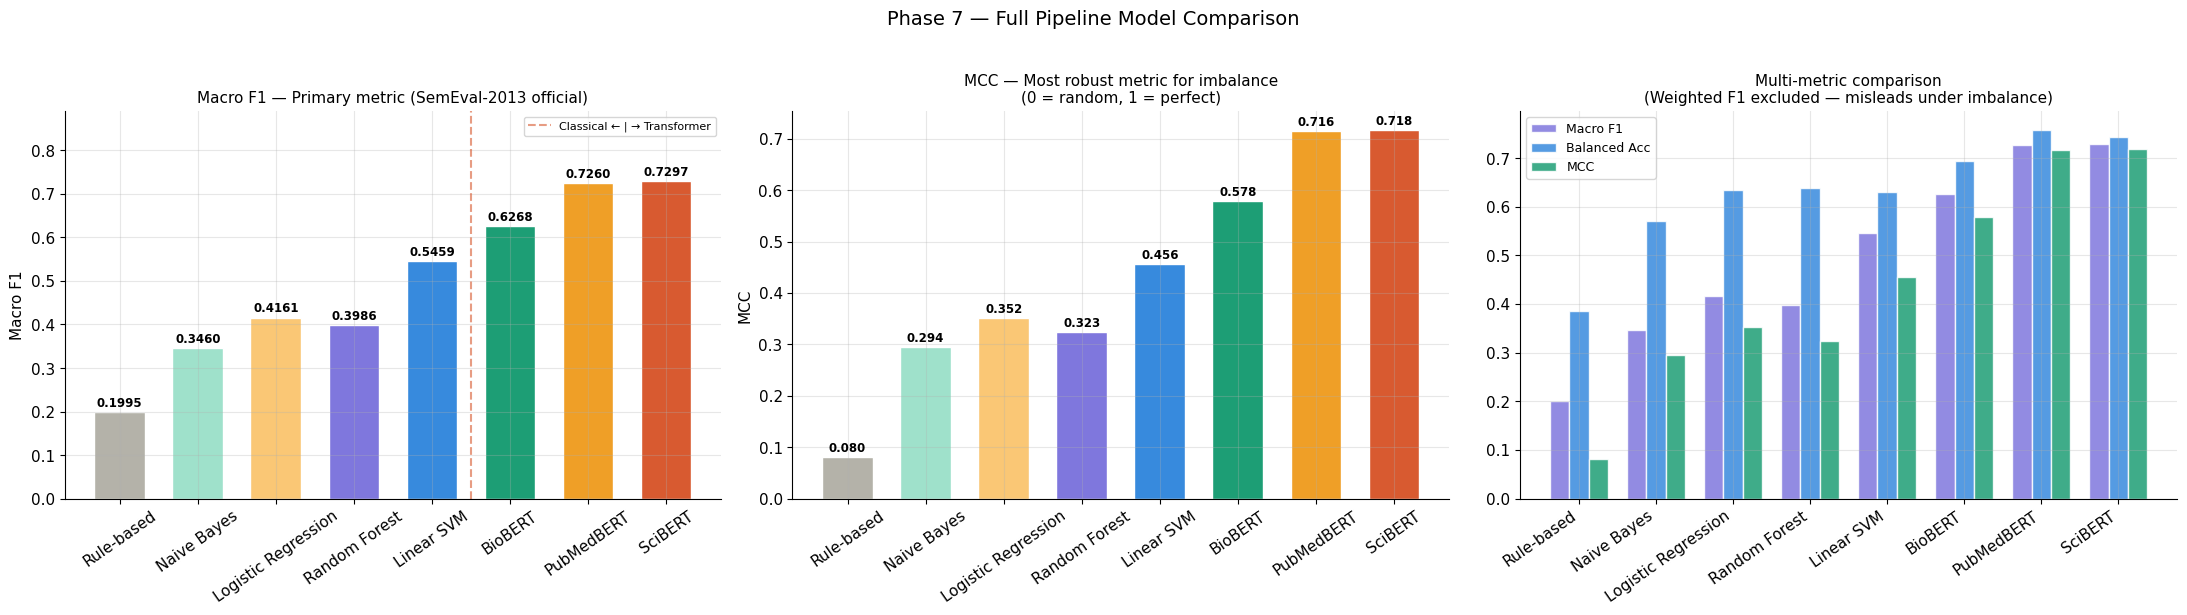

Saved -> viz1_full_comparison.png


In [5]:
colours   = [MODEL_COLOURS.get(m, '#888780') for m in available]
macro_f1s = [f1_score(y_test, all_preds[m], average='macro', zero_division=0) for m in available]
mcc_vals  = [matthews_corrcoef(y_test, all_preds[m]) for m in available]
bal_accs  = [balanced_accuracy_score(y_test, all_preds[m]) for m in available]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ── Macro F1 ──────────────────────────────────────────────────────
bars = axes[0].bar(available, macro_f1s, color=colours, edgecolor='white', width=0.65)
for bar, val in zip(bars, macro_f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
# Tier boundary
classical_in_avail = [m for m in available if model_type(m) == 'Classical ML']
trans_in_avail     = [m for m in available if model_type(m) == 'Transformer']
if classical_in_avail and trans_in_avail:
    boundary = (available.index(classical_in_avail[-1]) + available.index(trans_in_avail[0])) / 2
    axes[0].axvline(boundary, color='#D85A30', linestyle='--', alpha=0.6,
                    label='Classical ← | → Transformer')
    axes[0].legend(fontsize=8)
axes[0].set_title('Macro F1 — Primary metric (SemEval-2013 official)', fontsize=11)
axes[0].set_ylabel('Macro F1')
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_ylim(0, max(macro_f1s) * 1.22)

# ── MCC ───────────────────────────────────────────────────────────
bars2 = axes[1].bar(available, mcc_vals, color=colours, edgecolor='white', width=0.65)
for bar, val in zip(bars2, mcc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[1].set_title('MCC — Most robust metric for imbalance\n(0 = random, 1 = perfect)', fontsize=11)
axes[1].set_ylabel('MCC')
axes[1].tick_params(axis='x', rotation=35)

# ── Multi-metric grouped bar ───────────────────────────────────────
x = np.arange(len(available))
w = 0.25
axes[2].bar(x - w, macro_f1s, w, label='Macro F1', color='#7F77DD', alpha=0.85, edgecolor='white')
axes[2].bar(x,     bal_accs,  w, label='Balanced Acc', color='#378ADD', alpha=0.85, edgecolor='white')
axes[2].bar(x + w, mcc_vals,  w, label='MCC', color='#1D9E75', alpha=0.85, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(available, rotation=35, ha='right')
axes[2].set_title('Multi-metric comparison\n(Weighted F1 excluded — misleads under imbalance)', fontsize=11)
axes[2].legend(fontsize=9)

plt.suptitle('Phase 7 — Full Pipeline Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'viz1_full_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> viz1_full_comparison.png')

## 6. Visualisation 2 — Per-Class F1 Heatmap

Shows where each model struggles. Key patterns:
- `advise` — typically strongest (distinctive vocabulary: *contraindicated*, *avoid*, *monitor*)
- `int` — typically weakest (96 test samples, generic language)
- Transformers should show more uniform improvement across all classes

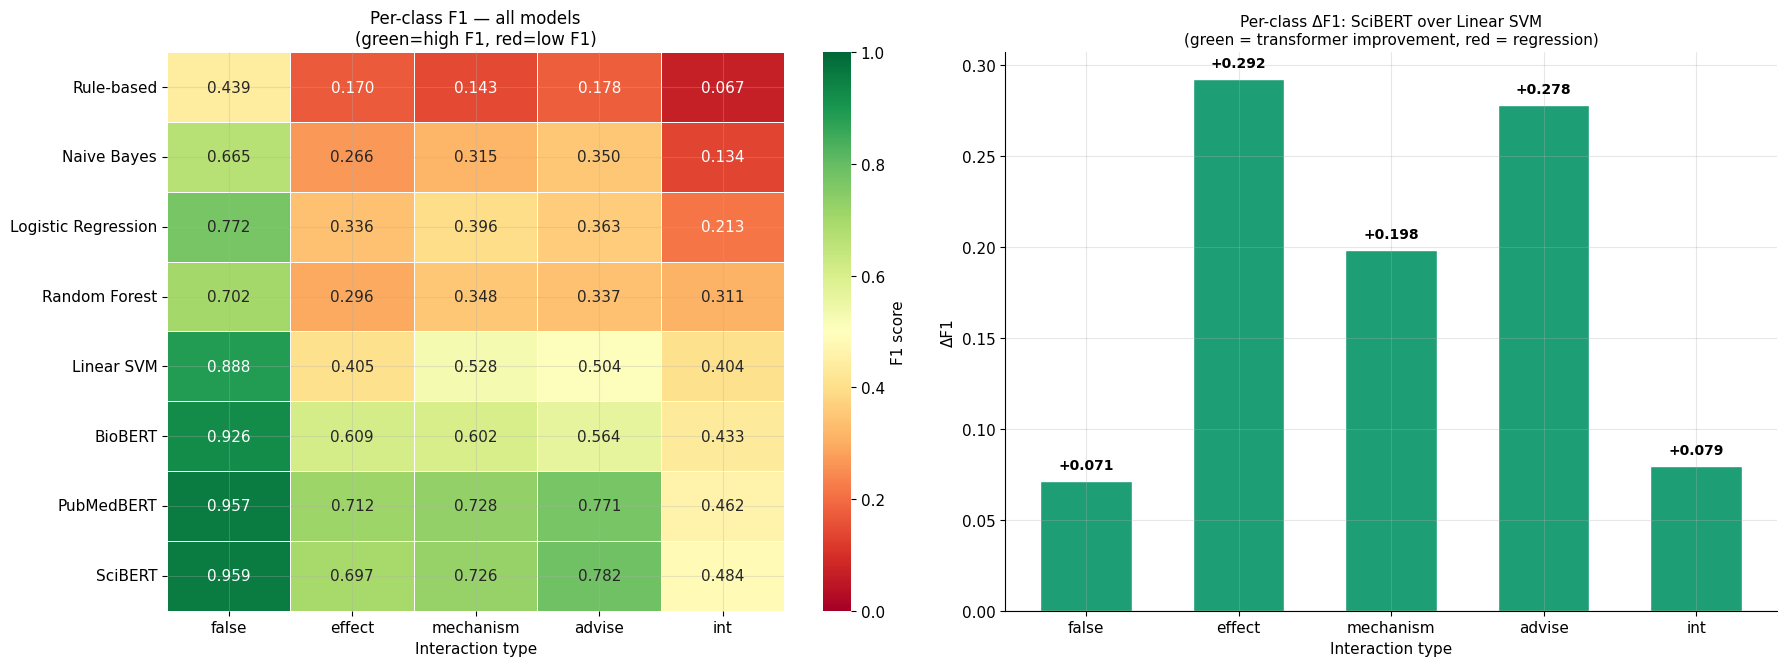

Saved -> viz2_perclass_heatmap.png


In [6]:
per_class = {}
for name in available:
    rep = classification_report(y_test, all_preds[name], target_names=CLASS_NAMES,
                                output_dict=True, zero_division=0)
    per_class[name] = [rep[lbl]['f1-score'] for lbl in LABEL_ORDER]

hm_df = pd.DataFrame(per_class, index=LABEL_ORDER).T.reindex(available)

fig, axes = plt.subplots(1, 2, figsize=(18, max(4, len(available) * 0.85)))

# Main heatmap
sns.heatmap(hm_df, ax=axes[0], annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, vmin=0, vmax=1, cbar_kws={'label': 'F1 score'})
axes[0].set_title('Per-class F1 — all models\n(green=high F1, red=low F1)', fontsize=12)
axes[0].set_xlabel('Interaction type')

# Delta: best transformer vs best classical
if best_trans and best_clf and best_trans in hm_df.index and best_clf in hm_df.index:
    delta = hm_df.loc[best_trans] - hm_df.loc[best_clf]
    bar_cols = ['#1D9E75' if v >= 0 else '#D85A30' for v in delta]
    axes[1].bar(LABEL_ORDER, delta.values, color=bar_cols, edgecolor='white', width=0.6)
    axes[1].axhline(0, color='black', linewidth=0.8, alpha=0.5)
    for i, val in enumerate(delta.values):
        axes[1].text(i, val + (0.005 if val >= 0 else -0.015),
                     f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top',
                     fontsize=10, fontweight='bold')
    axes[1].set_title(f'Per-class ΔF1: {best_trans} over {best_clf}\n'
                      f'(green = transformer improvement, red = regression)', fontsize=11)
    axes[1].set_xlabel('Interaction type')
    axes[1].set_ylabel('ΔF1')
else:
    axes[1].text(0.5, 0.5, 'Run Phase 6 notebooks first\nto see transformer delta',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'viz2_perclass_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> viz2_perclass_heatmap.png')

## 7. Visualisation 3 — Three-Way Transformer Comparison

Direct head-to-head comparison of BioBERT vs PubMedBERT vs SciBERT on every class. This answers **RQ3**: which transformer performs best, and does the biomedical-specific pre-training pay off?

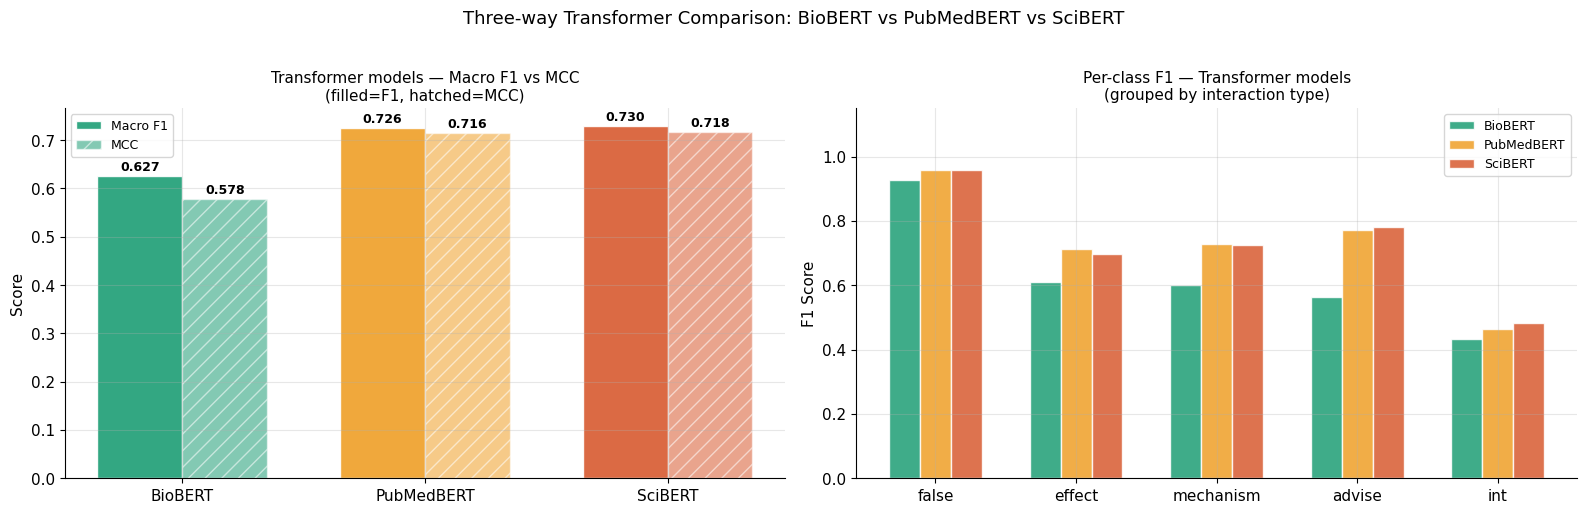

Saved -> viz3_transformer_threeway.png


In [7]:
trans_available = [m for m in ['BioBERT', 'PubMedBERT', 'SciBERT'] if m in all_preds]

if not trans_available:
    print('No transformer predictions available. Run Phase 6a/6b/6c first.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: Macro F1 + MCC side-by-side
    x = np.arange(len(trans_available))
    w = 0.35
    t_f1s = [f1_score(y_test, all_preds[m], average='macro', zero_division=0) for m in trans_available]
    t_mcc = [matthews_corrcoef(y_test, all_preds[m]) for m in trans_available]
    t_cols = [MODEL_COLOURS.get(m,'#888') for m in trans_available]

    b1 = axes[0].bar(x - w/2, t_f1s, w, label='Macro F1', color=t_cols, alpha=0.9, edgecolor='white')
    b2 = axes[0].bar(x + w/2, t_mcc, w, label='MCC',      color=t_cols, alpha=0.55, edgecolor='white', hatch='//')
    for bar, val in list(zip(b1,t_f1s)) + list(zip(b2,t_mcc)):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(trans_available)
    axes[0].set_title('Transformer models — Macro F1 vs MCC\n(filled=F1, hatched=MCC)', fontsize=11)
    axes[0].set_ylabel('Score')
    axes[0].legend(fontsize=9)

    # Right: Per-class F1 grouped bar
    n_trans = len(trans_available)
    x2 = np.arange(len(LABEL_ORDER))
    bar_width = 0.22
    for j, (tname, tcol) in enumerate([(m, MODEL_COLOURS.get(m,'#888')) for m in trans_available]):
        rep = classification_report(y_test, all_preds[tname], target_names=CLASS_NAMES,
                                    output_dict=True, zero_division=0)
        f1s = [rep[lbl]['f1-score'] for lbl in LABEL_ORDER]
        offset = (j - n_trans/2 + 0.5) * bar_width
        axes[1].bar(x2 + offset, f1s, bar_width, label=tname, color=tcol, alpha=0.85, edgecolor='white')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(LABEL_ORDER)
    axes[1].set_title('Per-class F1 — Transformer models\n(grouped by interaction type)', fontsize=11)
    axes[1].set_ylabel('F1 Score')
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(0, 1.15)

    plt.suptitle('Three-way Transformer Comparison: BioBERT vs PubMedBERT vs SciBERT', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'viz3_transformer_threeway.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> viz3_transformer_threeway.png')

## 8. Visualisation 4 — Confusion Matrices (One Per Tier)

Normalised confusion matrices for the best model from each tier (Rule-based, Classical ML, Transformer), enabling a direct visual comparison of error patterns.

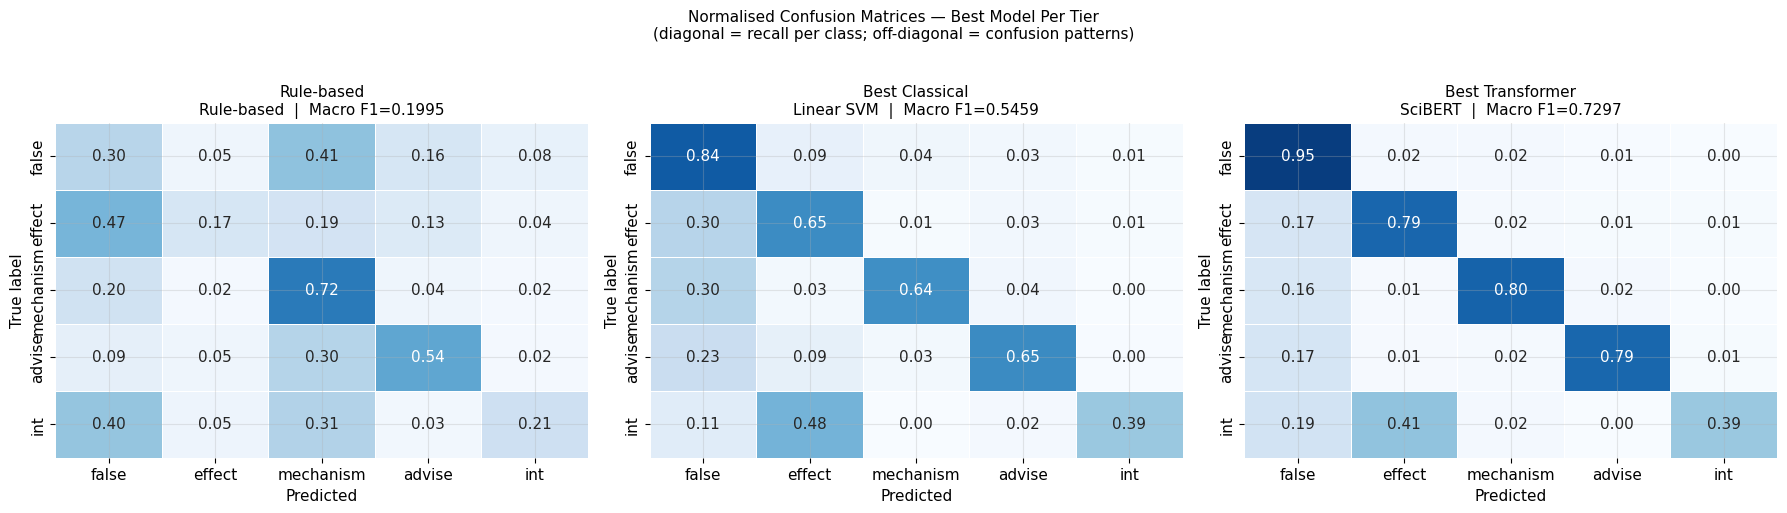

Saved -> viz4_confusion_matrices.png


In [8]:
showcase = {}
for tier, label in [('Rule-based','Rule-based'), ('Classical ML','Best Classical'), ('Transformer','Best Transformer')]:
    tier_rows = full_df[full_df['Type']==tier]
    if not tier_rows.empty:
        best_in_tier = tier_rows.iloc[0]['Model']
        if best_in_tier in all_preds:
            showcase[label] = best_in_tier

n_panels = len(showcase)
if n_panels == 0:
    print('No predictions available for showcase.')
else:
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))
    if n_panels == 1:
        axes = [axes]

    idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]

    for ax, (panel_label, model_name) in zip(axes, showcase.items()):
        preds = all_preds[model_name]
        cm     = confusion_matrix(y_test, preds)
        cm_ord = cm[np.ix_(idx, idx)]
        rsums  = cm_ord.sum(axis=1, keepdims=True)
        rsums[rsums == 0] = 1
        cm_norm = cm_ord / rsums

        f1 = f1_score(y_test, preds, average='macro', zero_division=0)
        sns.heatmap(cm_norm, ax=ax, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
                    vmin=0, vmax=1, cbar=False, linewidths=0.5)
        ax.set_title(f'{panel_label}\n{model_name}  |  Macro F1={f1:.4f}', fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True label')

    plt.suptitle('Normalised Confusion Matrices — Best Model Per Tier\n'
                 '(diagonal = recall per class; off-diagonal = confusion patterns)', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'viz4_confusion_matrices.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> viz4_confusion_matrices.png')

## 9. Error Analysis

Three levels of analysis:
1. **Dangerous misses** — real interactions predicted as `false` (highest clinical risk)
2. **Persistent errors** — samples every model gets wrong (hard cases, corpus noise)
3. **Failure mode categorisation** — linguistic patterns in the best model's errors

In [9]:
if best_model not in all_preds:
    print(f'Best model ({best_model}) predictions not available.')
else:
    best_col = best_model.lower().replace(' ','_').replace('-','_') + '_pred'
    interaction_classes = [l for l in LABEL_ORDER if l != 'false']

    test_df['true_label'] = test_df['interaction_type']
    test_df[best_col]     = [ID2LABEL[p] for p in all_preds[best_model]]
    errors   = test_df[test_df[best_col] != test_df['true_label']]
    correct  = test_df[test_df[best_col] == test_df['true_label']]

    print(f'Best model: {best_model}')
    print(f'Correct   : {len(correct):,} / {len(test_df):,} ({len(correct)/len(test_df)*100:.1f}%)')
    print(f'Errors    : {len(errors):,}  ({len(errors)/len(test_df)*100:.1f}%)')

    print('\nTop error patterns (true → predicted):')
    errs = errors.groupby(['true_label', best_col]).size().reset_index(name='count')
    print(errs.sort_values('count', ascending=False).head(12).to_string(index=False))

    # Dangerous misses
    dangerous = errors[
        (errors['true_label'].isin(interaction_classes)) &
        (errors[best_col] == 'false')
    ]
    print(f'\nDangerous misses (true=interaction, predicted=false): {len(dangerous):,}')
    print(f'  = {len(dangerous)/len(errors)*100:.1f}% of all errors')
    print('  These are real interactions the model failed to detect.\n')
    for _, row in dangerous.head(5).iterrows():
        sent = str(row.get('sentence_masked', row.get('sentence_original','')))
        print(f"  True: {row['true_label']:<12}  Sentence: {sent[:120]}")
    print()

    # Persistent errors — wrong across ALL available models
    mask_all_wrong = pd.Series(True, index=test_df.index)
    for m in available:
        col = m.lower().replace(' ','_').replace('-','_') + '_pred'
        test_df[col] = [ID2LABEL[p] for p in all_preds[m]]
        mask_all_wrong &= (test_df[col] != test_df['true_label'])

    persistent = test_df[mask_all_wrong]
    print(f'Persistent errors (all {len(available)} models wrong): {len(persistent):,} ({len(persistent)/len(test_df)*100:.1f}%)')
    print('True label distribution of persistent errors:')
    print(persistent['true_label'].value_counts().to_string())

Best model: SciBERT
Correct   : 6,125 / 6,657 (92.0%)
Errors    : 532  (8.0%)

Top error patterns (true → predicted):
true_label scibert_pred  count
     false       effect    127
     false    mechanism    111
    effect        false     61
 mechanism        false     48
     false       advise     39
       int       effect     39
    advise        false     38
       int        false     18
     false          int     15
    effect    mechanism      7
 mechanism       advise      7
    effect       advise      4

Dangerous misses (true=interaction, predicted=false): 165
  = 31.0% of all errors
  These are real interactions the model failed to detect.

  True: mechanism     Sentence: DRUG1 decreases the elimination of DRUG2 causing an increase in overall exposure . The addition of methadone has no clin
  True: effect        Sentence: DRUG2: Because of the occurrence of serious cardiac dysrhythmias secondary to prolongation of the QTc interval in patien
  True: effect        Sentence:

## 10. Final Research Question Answers

In [11]:
print('='*80)
print('  PHASE 7 — RESEARCH QUESTIONS ANSWERED')
print('='*80)

rb_f1   = f1_score(y_test, all_preds['Rule-based'], average='macro', zero_division=0) if 'Rule-based' in all_preds else None
clf_f1  = f1_score(y_test, all_preds[best_clf],     average='macro', zero_division=0) if best_clf and best_clf in all_preds else None
trans_f1= f1_score(y_test, all_preds[best_trans],   average='macro', zero_division=0) if best_trans and best_trans in all_preds else None

print()
if rb_f1 and clf_f1:
    ans = 'YES' if clf_f1 > rb_f1 else 'NO'
    print(f'  RQ1: Does classical ML beat keyword matching?')
    print(f'       {ans}. {best_clf} ({clf_f1:.4f}) vs Rule-based ({rb_f1:.4f})  Δ={clf_f1-rb_f1:+.4f}')

if clf_f1 and trans_f1:
    ans = 'YES' if trans_f1 > clf_f1 else 'NO'
    print(f'\n  RQ2: Do transformers beat classical ML?')
    print(f'       {ans}. {best_trans} ({trans_f1:.4f}) vs {best_clf} ({clf_f1:.4f})  Δ={trans_f1-clf_f1:+.4f}')

if trans_available:
    t_f1s_dict = {m: f1_score(y_test, all_preds[m], average='macro', zero_division=0) for m in trans_available}
    best_t = max(t_f1s_dict, key=t_f1s_dict.get)
    print(f'\n  RQ3: Which transformer performs best?')
    for m, v in sorted(t_f1s_dict.items(), key=lambda x: -x[1]):
        mark = ' <- BEST' if m == best_t else ''
        print(f'       {m:<14} Macro F1={v:.4f}{mark}')

if stat_results:
    print(f'\n  RQ4: Are differences statistically significant? (McNemar\'s test)')
    for test, info in stat_results.items():
        sig = 'YES (p<0.05)' if info['significant'] else 'NO (p≥0.05)'
        print(f'       {test:<45} {sig}  (p={info["p_value"]:.4f})')

print(f'\n  Overall best model: {best_model} (Macro F1 = {f1_score(y_test, all_preds[best_model], average="macro", zero_division=0):.4f})')
print()
print(f'  Files saved to {DAT_DIR}:')
for fname in sorted(os.listdir(DAT_DIR)):
    fpath = os.path.join(DAT_DIR, fname)
    if os.path.isfile(fpath):
        print(f'    {fname:<45} {os.path.getsize(fpath)/1024:8.1f} KB')
print()

  PHASE 7 — RESEARCH QUESTIONS ANSWERED

  RQ1: Does classical ML beat keyword matching?
       YES. Linear SVM (0.5459) vs Rule-based (0.1995)  Δ=+0.3464

  RQ2: Do transformers beat classical ML?
       YES. SciBERT (0.7297) vs Linear SVM (0.5459)  Δ=+0.1837

  RQ3: Which transformer performs best?
       SciBERT        Macro F1=0.7297 <- BEST
       PubMedBERT     Macro F1=0.7260
       BioBERT        Macro F1=0.6268

  RQ4: Are differences statistically significant? (McNemar's test)
       Best Transformer vs Best Classical            YES (p<0.05)  (p=0.0000)
       Best Classical vs Rule-based                  YES (p<0.05)  (p=0.0000)
       BioBERT vs PubMedBERT                         YES (p<0.05)  (p=0.0000)
       BioBERT vs SciBERT                            YES (p<0.05)  (p=0.0000)
       PubMedBERT vs SciBERT                         NO (p≥0.05)  (p=0.3971)

  Overall best model: SciBERT (Macro F1 = 0.7297)

  Files saved to outputs/data:
    full_comparison.csv             